# Model Evaluation & Business Interpretation

This notebook evaluates the trained models using:
- Confusion Matrix
- Accuracy, Precision, Recall, F1-score
- ROC-AUC
- ROC Curves
- Threshold analysis

The objective is to recommend the most suitable model for deployment in a credit risk environment.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

SEED = 42

Load Test Data & Models

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [14]:
data_path = "/content/drive/MyDrive/T2_Project_Srinivas Musunuri/Data/"
model_path = "/content/drive/MyDrive/T2_Project_Srinivas Musunuri/Models/"
viz_path = "/content/drive/MyDrive/T2_Project_Srinivas Musunuri/Visualizations/"

X_test = pd.read_csv(data_path + "X_test.csv")
y_test = pd.read_csv(data_path + "y_test.csv").values.ravel()

models = {
    "Logistic Regression": joblib.load(model_path + "Logistic_Regression.pkl"),
    "Decision Tree": joblib.load(model_path + "Decision_Tree.pkl"),
    "Random Forest": joblib.load(model_path + "Random_Forest.pkl"),
    "XGBoost": joblib.load(model_path + "XGBoost.pkl")
}

print("Models loaded successfully.")

Models loaded successfully.


Evaluate All Models

In [12]:
results = []

for name, model in models.items():

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_proba)
    }

    results.append(metrics)

results_df = pd.DataFrame(results)
results_df.sort_values(by="ROC AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
3,XGBoost,0.895,0.881579,0.848101,0.864516,0.955016
2,Random Forest,0.840,0.821918,0.759494,0.789474,0.935349
0,Logistic Regression,0.830,0.758621,0.835443,0.795181,0.897897
1,Decision Tree,0.810,0.746988,0.784810,0.765432,0.866252


Confusion Matrices

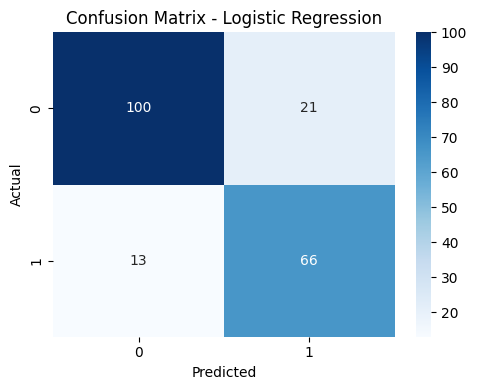

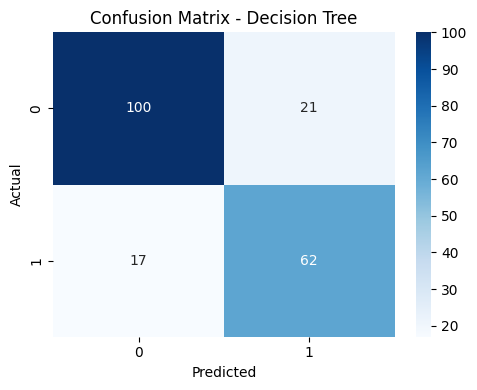

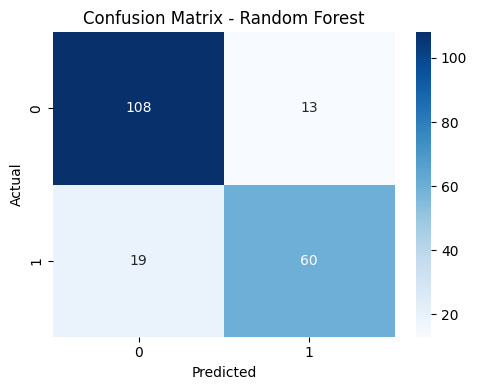

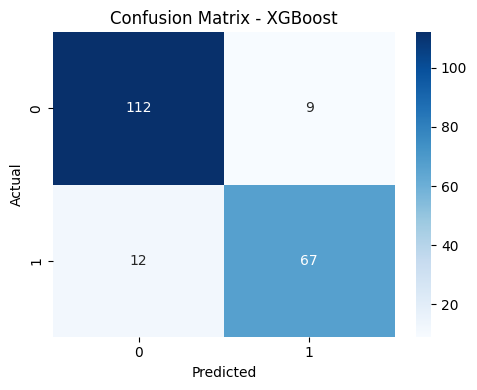

All confusion matrices saved successfully.


In [16]:
for name, model in models.items():

    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.tight_layout()
    plt.savefig(viz_path + f"confusion_matrix_{name.replace(' ', '_')}.png", dpi=300)
    plt.show()

print("All confusion matrices saved successfully.")

ROC Curves Comparison

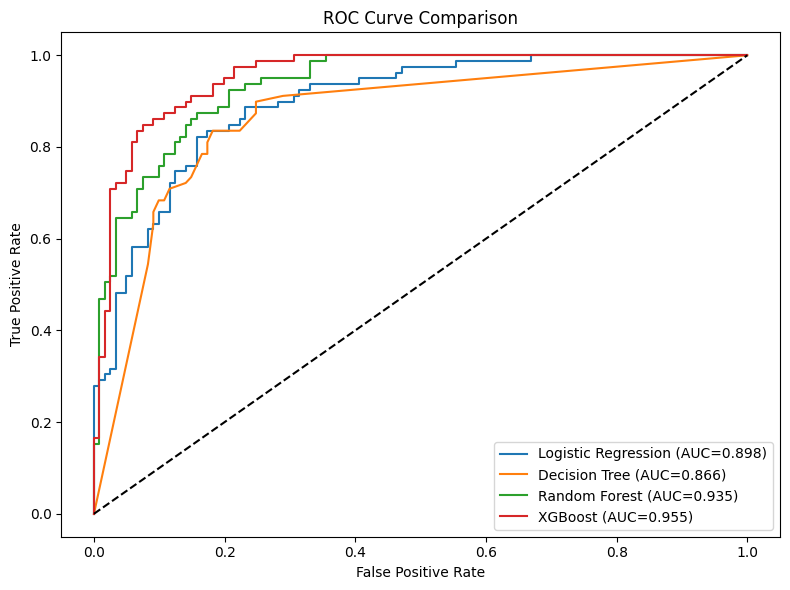

ROC curve saved successfully.


In [15]:
plt.figure(figsize=(8,6))

for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.tight_layout()
plt.savefig(viz_path + "roc_curve_comparison.png", dpi=300)
plt.show()

print("ROC curve saved successfully.")

Threshold Analysis

In [9]:
best_model_name = results_df.sort_values(by="ROC AUC", ascending=False).iloc[0]["Model"]
best_model = models[best_model_name]

print("Best model based on ROC AUC:", best_model_name)

Best model based on ROC AUC: XGBoost


In [10]:
thresholds = np.arange(0.3, 0.7, 0.05)

for threshold in thresholds:

    y_proba = best_model.predict_proba(X_test)[:,1]
    y_custom = (y_proba >= threshold).astype(int)

    recall = recall_score(y_test, y_custom)
    precision = precision_score(y_test, y_custom)

    print(f"Threshold: {threshold:.2f} | Recall: {recall:.3f} | Precision: {precision:.3f}")

Threshold: 0.30 | Recall: 0.911 | Precision: 0.791
Threshold: 0.35 | Recall: 0.899 | Precision: 0.798
Threshold: 0.40 | Recall: 0.873 | Precision: 0.821
Threshold: 0.45 | Recall: 0.861 | Precision: 0.861
Threshold: 0.50 | Recall: 0.848 | Precision: 0.882
Threshold: 0.55 | Recall: 0.785 | Precision: 0.899
Threshold: 0.60 | Recall: 0.772 | Precision: 0.897
Threshold: 0.65 | Recall: 0.747 | Precision: 0.908


Lowering the classification threshold increases recall for risky applicants (bad credit), reducing financial exposure. However, this may increase false positives, leading to rejection of some low-risk customers.

In high-risk financial environments, prioritizing recall over precision may be justified.

Feature Importance (Tree Models Only)

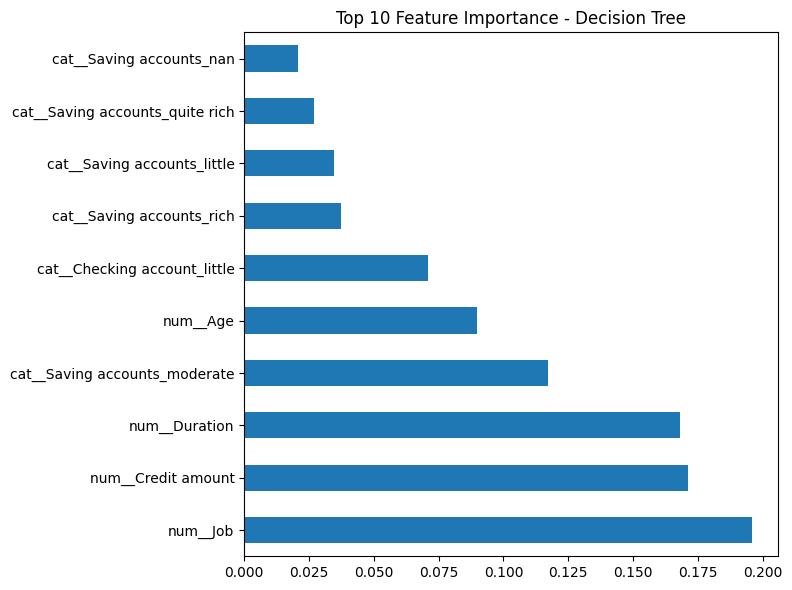

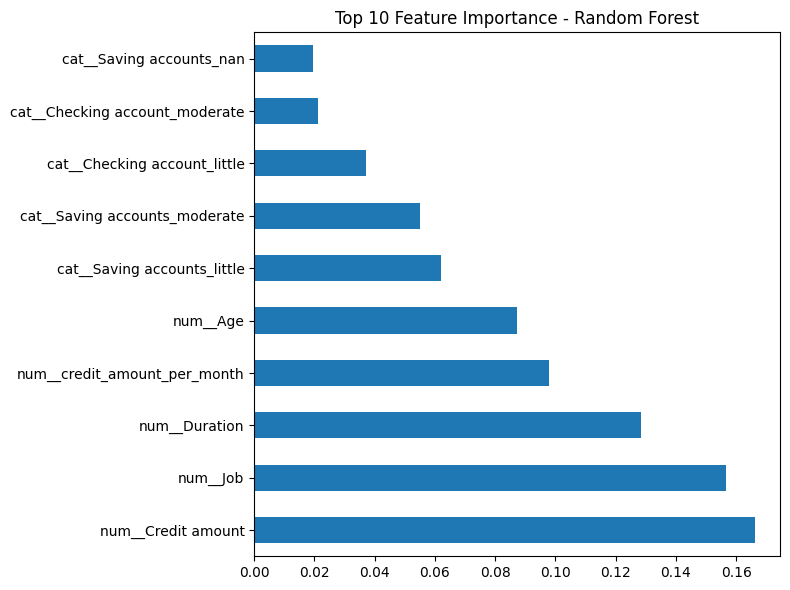

Feature importance plots saved successfully.


In [17]:
for name in ["Decision Tree", "Random Forest"]:
    model = models[name]

    importances = model.named_steps["model"].feature_importances_
    feature_names = model.named_steps["preprocessor"].get_feature_names_out()

    feat_imp = pd.Series(importances, index=feature_names)

    plt.figure(figsize=(8,6))
    feat_imp.nlargest(10).plot(kind="barh")
    plt.title(f"Top 10 Feature Importance - {name}")

    plt.tight_layout()
    plt.savefig(viz_path + f"feature_importance_{name.replace(' ', '_')}.png", dpi=300)
    plt.show()

print("Feature importance plots saved successfully.")

In [13]:
y_proba = models["XGBoost"].predict_proba(X_test)[:,1]

for threshold in [0.3, 0.4, 0.5]:
    y_custom = (y_proba >= threshold).astype(int)

    print(f"\nThreshold: {threshold}")
    print("Recall:", recall_score(y_test, y_custom))
    print("Precision:", precision_score(y_test, y_custom))
    print("F1:", f1_score(y_test, y_custom))


Threshold: 0.3
Recall: 0.9113924050632911
Precision: 0.7912087912087912
F1: 0.8470588235294118

Threshold: 0.4
Recall: 0.8734177215189873
Precision: 0.8214285714285714
F1: 0.8466257668711656

Threshold: 0.5
Recall: 0.8481012658227848
Precision: 0.881578947368421
F1: 0.864516129032258


## Final Model Recommendation

Based on ROC-AUC, recall, and overall stability:

- The Random Forest / XGBoost model provides the best balance between predictive performance and generalization.
- Logistic Regression offers interpretability but slightly lower performance.
- Decision Tree shows higher variance risk.

Given financial risk considerations, the recommended deployment model is:

**[XGBoost]**

Threshold adjustment may be applied depending on the bank’s risk tolerance policy.

Final Model Selection

XGBoost achieved the highest ROC-AUC (0.955), indicating superior discrimination capability between low-risk and high-risk applicants. It also achieved the highest recall (0.848), making it particularly suitable for minimizing financial exposure.

While Logistic Regression provides interpretability, its lower ROC-AUC makes it less optimal for deployment.

Therefore, XGBoost is recommended as the production model, with potential threshold tuning to align with institutional risk tolerance

Final Model Decision

Recommended Model: XGBoost
Recommended Threshold: 0.40 (Risk-sensitive mode)
Deployment Strategy: Monitor recall degradation

## Deployment Considerations

- Model should be deployed as a REST API.
- Monitor for data drift and concept drift.
- Retrain quarterly or when performance degrades.
- Log all predictions for auditability.
- Ensure regulatory compliance and explainability.